In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
 style='whitegrid',
 palette='muted',
 font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')


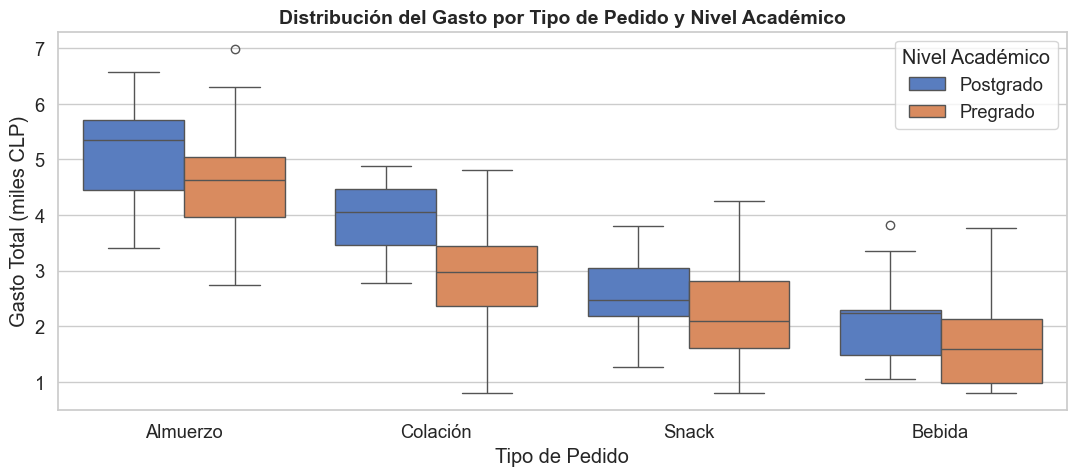

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,
    x='tipo_pedido',
    y='gasto_total',
    hue='nivel_academico',
    palette='muted',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'], 
    ax=ax
)

ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')

plt.tight_layout()
plt.show() 

Respuestas preguntas de analisis 

1.Mayor variabilidad: El tipo de pedido "Colación" y "Snack" presentan una desviación estándar similar (aproximadamente 0.87 y 0.88 respectivamente). Al observar el gráfico generado, la caja (que representa el Rango Intercuartílico, IQR) más alargada indicará visualmente la mayor dispersión central de los datos.

2.Outliers: Debe observar los puntos en forma de rombo que se ubican fuera de los "bigotes" del gráfico. Estos suelen aparecer en los pedidos de mayor valor ("Almuerzo") cuando un estudiante realiza un gasto atípicamente alto en comparación a la mediana de su grupo académico.

3.Diferencia sistemática: La diferencia sistemática se puede identificar observando la línea central (mediana) de cada caja. Si las cajas del nivel "Pregrado" están consistentemente por debajo o por encima de las de "Postgrado" en categorías como "Almuerzo", existe una diferencia en el patrón de gasto.

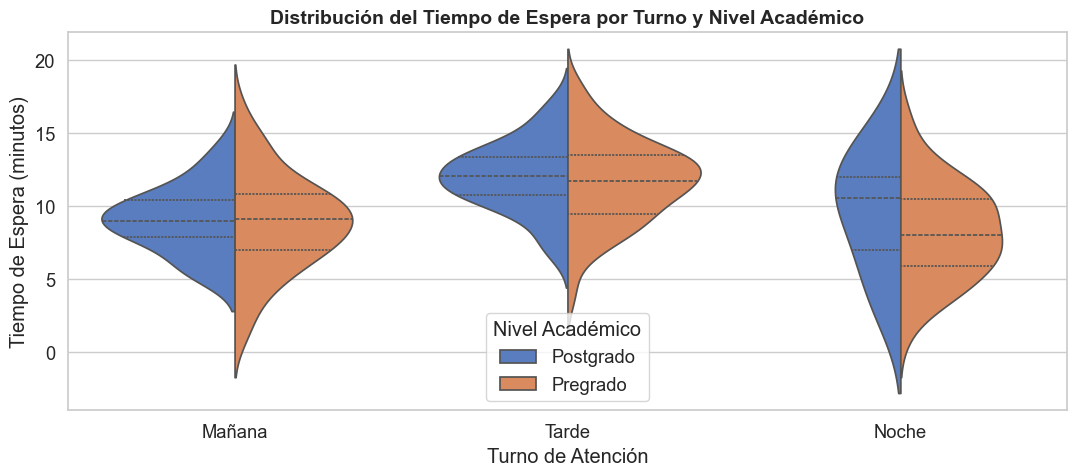

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(
    data=df,
    x='turno',
    y='tiempo_espera_min',
    hue='nivel_academico',
    split=True,
    inner='quartile', 
    palette='muted',
    order=['Mañana', 'Tarde', 'Noche'],
    ax=ax
)

ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')

plt.tight_layout()
plt.show()

Respuestas preguntas de analisis. 

1.Mayor tiempo de espera mediano: Según los datos extraídos, el turno de la Tarde presenta la mayor mediana de espera (11.7 minutos), superando a la Mañana (9.1 min) y Noche (8.4 min). Desde una perspectiva operacional, tiene pleno sentido, ya que coincide con el horario de mayor flujo de demanda por almuerzos.

2.Simetría: Visualmente en el violinplot, si la "panza" del violín es más ancha en la parte inferior y se alarga hacia arriba de forma desigual, presenta una asimetría positiva (sesgo hacia tiempos más altos debido a retrasos puntuales).

3.Boxplot vs Violinplot: El violinplot incluye una estimación de densidad kernel (KDE). A diferencia del boxplot, el diagrama de violín permite observar si los datos tienen una distribución bimodal (dos picos de concentración de personas) o múltiple, información que la caja rígida del boxplot oculta.

Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

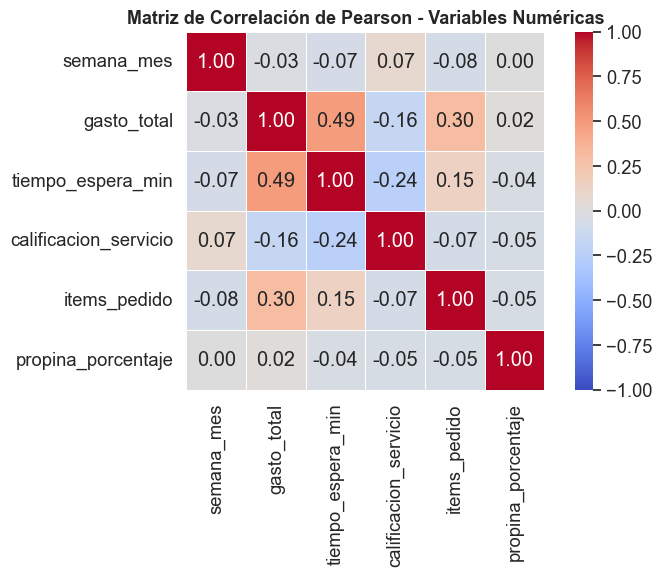

In [4]:
# Paso 1: Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include=[np.number]) # Se utiliza np.number
print('Variables numéricas:', list(num_cols.columns))

# Paso 2: Calcular la matriz de correlación de Pearson
corr_matrix = num_cols.corr() # Función corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))


fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson - Variables Numéricas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Respuestas a las preguntas de analisis 

1.Mayor correlación positiva: El par con mayor asociación es gasto_total y tiempo_espera_min con un valor de r = 0.49. Explicación causal: Los pedidos que involucran mayor gasto (como los almuerzos completos) requieren de una mayor preparación en cocina que pedidos económicos (como una bebida), aumentando el tiempo de espera.

2.Correlación negativa: Sí, existe una correlación negativa moderada de r = -0.24 entre tiempo_espera_min y calificacion_servicio. Es operativamente razonable: a medida que el cliente espera más minutos por su pedido, su nivel de satisfacción con el servicio disminuye.  

3.Menor correlación: La variable propina_porcentaje tiene correlaciones cercanas a cero con casi todas las demás variables numéricas 0.01 con gasto, -0.04 con tiempo, -0.05 con calificación). Esto implica que la propina es un comportamiento errático que no está linealmente determinado por factores como el tiempo, el gasto o la calificación del servicio.

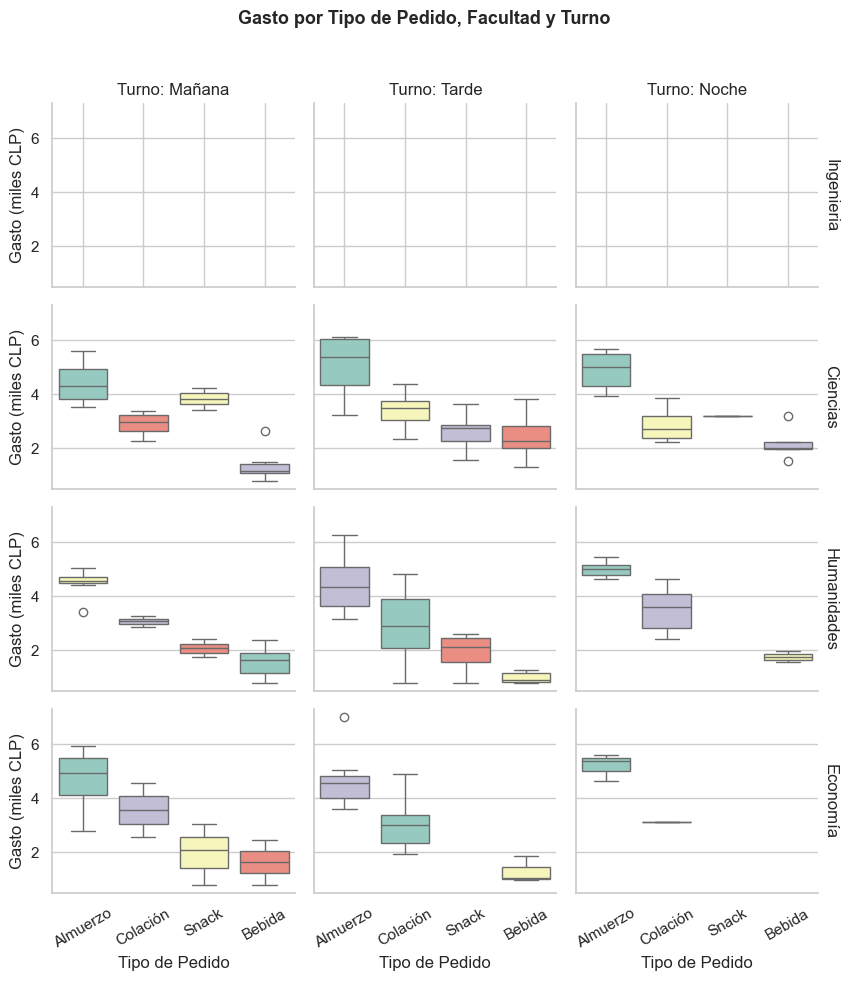

In [7]:
sns.set_theme(style='whitegrid', font_scale=1.0)

g = sns.FacetGrid(
    data=df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingenieria', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    hue='tipo_pedido', 
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
    legend=False
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')

g.figure.suptitle(
    'Gasto por Tipo de Pedido, Facultad y Turno',
    y=1.02, fontsize=13, fontweight='bold'
)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

Respuestas preguntas de analisis 

1.Gasto mediano en Almuerzo: Según el cálculo agrupado, la combinación con mayor gasto mediano en almuerzos se da en Tarde Ciencias y Noche Economía (alcanzando cifras cercanas a los 5.37 miles CLP). El menor gasto se observa en Mañana - Ciencias (4.30 miles CLP).

2.Patrón consistente: Al observar la cuadrícula, notará que el patrón general de gasto aumenta en el turno de la tarde para todas las facultades debido al horario de almuerzo. Sin embargo, hay diferencias; por ejemplo, algunas facultades mantienen un consumo moderado y estable de snacks en la noche, mientras que otras disminuyen drásticamente.

3.Ventajas de FacetGrid: FacetGrid automatiza la creación de subfiguras y alinea los ejes ("X" e "Y") de manera uniforme para todas las celdas. Esto permite una comparación directa y justa sin distorsiones visuales, requiriendo significativamente menos código que construir iterativamente cada subplot manual en Matplotlib.

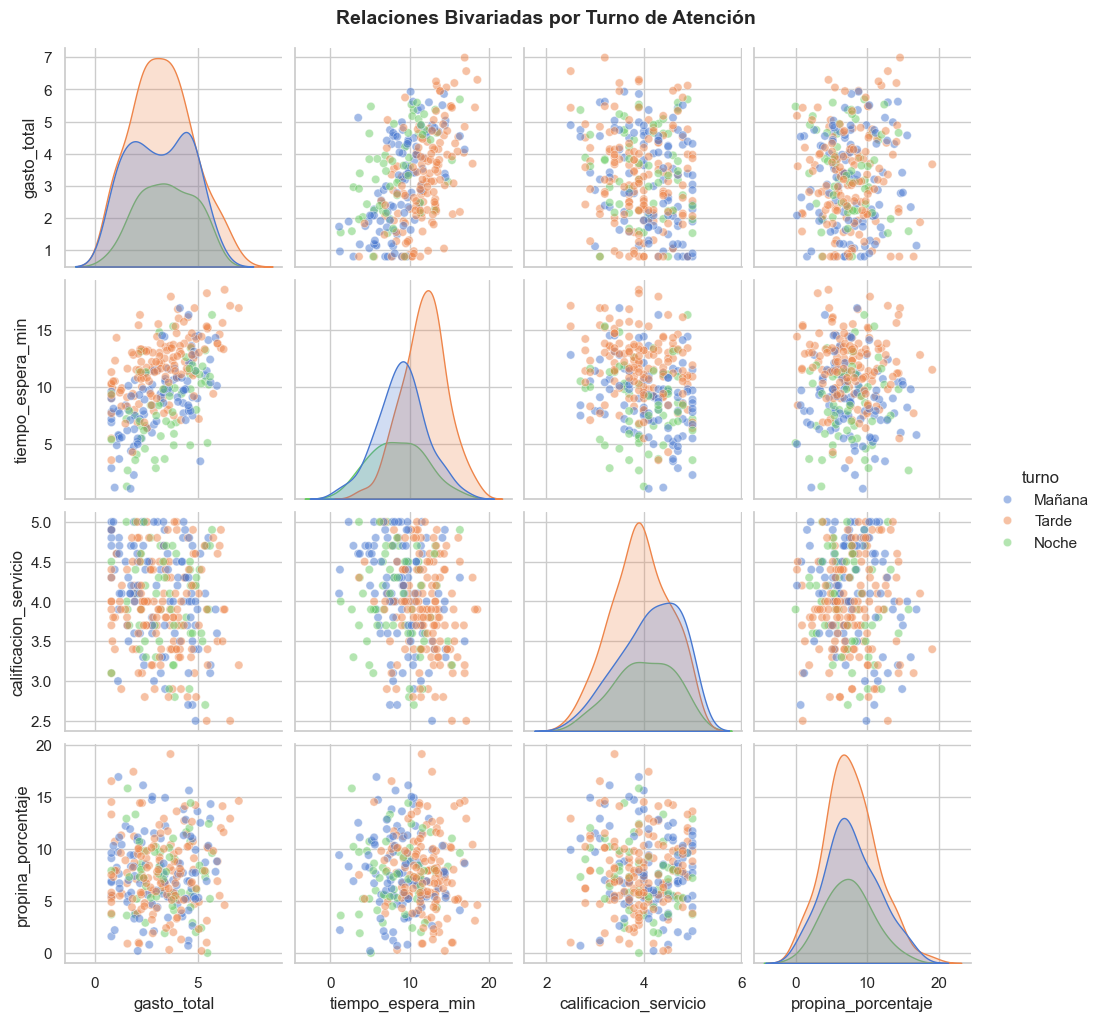

In [6]:
# Seleccionar variables numéricas de interés
vars_plot = ['gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'propina_porcentaje']

g = sns.pairplot(
    data=df[vars_plot + ['turno']],
    hue='turno',
    hue_order=['Mañana', 'Tarde', 'Noche'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5},
    palette='muted'
)

g.figure.suptitle(
    'Relaciones Bivariadas por Turno de Atención',
    y=1.02, fontsize=14, fontweight='bold'
)

# Exportación en diferentes formatos solicitados
g.savefig('desafio_pairplot.svg', bbox_inches='tight') 
g.savefig('desafio_pairplot.pdf', bbox_inches='tight')
g.savefig('desafio_pairplot.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
Respuestas preguntas de analisis

1.